# 03. Descriptive analysis

This notebook constructs the final paper sample and summarizes the empirical promotion environment. It reports product and store coverage, observed promotion depths, promotion frequency, and isolated promotion episodes used to describe post-promotion demand patterns.

Promotion-event outcomes are evaluated relative to predictions from the selected rolling demand model. The resulting event paths are descriptive residualized patterns: they show how observed sales differ from the model-implied non-promotional baseline around historical promotion episodes.

The event study is used to motivate and assess the behavioral calibration. It is not interpreted as a causal event-study design because historical promotions are not randomly assigned and may respond to anticipated demand conditions. The notebook produces the descriptive sample table, the promotion-depth figure, and the residualized post-promotion diagnostics used in the paper.

## 1. Imports and configuration

In [1]:
# Import numerical, tabular, plotting, and filesystem utilities used throughout the notebook.
from __future__ import annotations
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the repository from either the repository root or notebooks/.
CURRENT_DIR = Path.cwd().resolve()

POSSIBLE_ROOTS = [CURRENT_DIR, CURRENT_DIR.parent]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (root / "data" / "processed").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from the "
        "repository root or the notebooks directory."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

DEMAND_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "demand"

TABLE_DIR = PROJECT_ROOT / "results" / "final" / "tables"

FIGURE_DIR = PROJECT_ROOT / "results" / "final" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Define all input, model, cache, and output locations in one place.
DEMAND_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_DATA_PATH = PROCESSED_DIR / "cereal_demand_model_data.parquet"

PRODUCT_LOOKUP_PATH = PROCESSED_DIR / "cereal_product_lookup.parquet"

SELECTED_PRODUCTS_PATH = TABLE_DIR / "selected_products.csv"

STORE_SELECTION_PATH = TABLE_DIR / "store_selection_table.csv"

PANEL_SELECTION_PATH = TABLE_DIR / "panel_selection_table.csv"

PRODUCT_SELECTION_PATH = TABLE_DIR / "product_selection_table.csv"

MODEL_DIR = PROJECT_ROOT / "results" / "models"

ROLLING_MODEL_DIR = MODEL_DIR / "product_promotion_rolling_ppml"

ROLLING_MANIFEST_PATH = (
    DEMAND_ARTIFACT_DIR / "demand_model_manifest.pkl"
)

PREDICTION_CONTEXT_PATH = (
    DEMAND_ARTIFACT_DIR / "demand_prediction_context.pkl"
)

CACHE_PATH = PROCESSED_DIR / "paper_selected_sample.parquet"

CACHE_MANIFEST_PATH = PROCESSED_DIR / "paper_selected_sample_manifest.json"

from dynamic_promotion_planning.config import load_analysis_config

# Load centrally governed analysis settings rather than duplicating constants here.
analysis_config = load_analysis_config()
demand_config = analysis_config.demand
behavioral_config = analysis_config.behavioral
support_config = analysis_config.support

TRAIN_SHARE = demand_config.train_share
CALIBRATION_SHARE = demand_config.calibration_share

# Historical information used to construct promotion-depth support.
# The test period is intentionally excluded.
SUPPORT_SPLITS = ("train", "calibration")

DEPTH_CLUSTER_WIDTH = support_config.bin_width
MIN_SUPPORT_OBSERVATIONS = support_config.minimum_observations
MIN_SUPPORT_PANELS = support_config.minimum_panels
MAX_POSITIVE_DEPTHS = support_config.maximum_positive_actions

# Rank supported depths by empirical coverage when no downstream action-grid file is available.
ACTION_SELECTION_RULE = "highest_support"

PRE_EVENT_WEEKS = behavioral_config.event_pre_weeks
POST_EVENT_WEEKS = behavioral_config.event_post_weeks

REQUIRE_SINGLE_WEEK_PROMOTION = True
REQUIRE_NO_OTHER_PROMOTION_IN_WINDOW = True


In [3]:
# Set event-study and cache controls, then verify that all upstream artifacts exist.
MIN_PRE_PERIOD_MEAN_SALES = 1e-8

EVENT_BOOTSTRAP_REPLICATIONS = 2_000

EVENT_BOOTSTRAP_SEED = 20260723

# Cache controls.
USE_CACHE = True

FORCE_REBUILD_CACHE = False

required_paths = [
    SOURCE_DATA_PATH,
    PRODUCT_LOOKUP_PATH,
    SELECTED_PRODUCTS_PATH,
    STORE_SELECTION_PATH,
    PANEL_SELECTION_PATH,
    PRODUCT_SELECTION_PATH,
    ROLLING_MANIFEST_PATH,
    PREDICTION_CONTEXT_PATH,
]

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    missing_text = "\n".join(f"  - {path}" for path in missing_paths)
    raise FileNotFoundError(
        "Required saved outputs are missing. Run notebooks 01 and 02 once, "
        f"then rerun this notebook:\n{missing_text}"
    )

print("Project root:", PROJECT_ROOT)

print("Source data:", SOURCE_DATA_PATH)

print("Output tables:", TABLE_DIR)

print("Output figures:", FIGURE_DIR)

from dynamic_promotion_planning.descriptives import (
    build_residualized_event_paths,
    format_depths,
    load_or_build_selected_sample,
    normalize_identifier,
    parse_boolean,
)

from dynamic_promotion_planning.paths import project_paths

Project root: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0
Source data: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\data\processed\cereal_demand_model_data.parquet
Output tables: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables
Output figures: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\figures


## 2. Load the saved selection decisions

In [4]:
# Load the product, store, and panel selections fixed by the preceding notebook.
selected_products_file = pd.read_csv(
    SELECTED_PRODUCTS_PATH,
    dtype={"upc": "string"},
)

selected_upcs = (
    normalize_identifier(selected_products_file["upc"])
    .dropna()
    .drop_duplicates()
    .tolist()
)

store_selection = pd.read_csv(
    STORE_SELECTION_PATH,
    dtype={"store": "string"},
)

store_selection["store"] = normalize_identifier(
    store_selection["store"]
)

# Retain every store that satisfies the pre-specified panel-availability rule.
selected_stores = (
    store_selection.loc[
        parse_boolean(store_selection["eligible"]),
        "store",
    ]
    .dropna()
    .drop_duplicates()
    .tolist()
)

panel_selection = pd.read_csv(
    PANEL_SELECTION_PATH,
    dtype={"store_upc": "string"},
)

panel_selection["store_upc"] = normalize_identifier(
    panel_selection["store_upc"]
)

# Use a set because panel membership is repeatedly tested while constructing the cache.
eligible_panels = set(
    panel_selection.loc[
        parse_boolean(panel_selection["eligible"]),
        "store_upc",
    ]
    .dropna()
    .tolist()
)

product_selection = pd.read_csv(
    PRODUCT_SELECTION_PATH,
    dtype={"upc": "string"},
)

product_selection["upc"] = normalize_identifier(
    product_selection["upc"]
)

In [5]:
# Fail early if any saved selection is empty, because later summaries would be misleading.
if not selected_upcs:
    raise ValueError("No selected products were found.")

if not selected_stores:
    raise ValueError("No selected stores were found.")

if not eligible_panels:
    raise ValueError("No eligible store-product panels were found.")

print(f"Selected products: {len(selected_upcs)}")

print(f"Selected stores: {len(selected_stores)}")

print(f"Eligible panels in saved audit table: {len(eligible_panels)}")

Selected products: 8
Selected stores: 83
Eligible panels in saved audit table: 664


## 3. Load or rebuild the compact selected-sample cache

In [6]:
# Load the compact analysis sample, rebuilding its cache only when requested or necessary.
selected_sample, cache_manifest = load_or_build_selected_sample(
    source_data_path=SOURCE_DATA_PATH,
    cache_path=CACHE_PATH,
    cache_manifest_path=CACHE_MANIFEST_PATH,
    selected_upcs=selected_upcs,
    selected_stores=selected_stores,
    eligible_panels=eligible_panels,
    use_cache=USE_CACHE,
    force_rebuild=FORCE_REBUILD_CACHE,
)

print(
    f"Selected sample: {len(selected_sample):,} rows, "
    f"{selected_sample['upc'].nunique()} products, "
    f"{selected_sample['store'].nunique()} stores."
)

Selected sample: 230,348 rows, 8 products, 83 stores.


## 4. Reconstruct the saved chronological split

In [7]:
# Reproduce the chronological train-calibration-test split used during model selection.
# Notebook 02 defines the split before product selection using all cleaned weeks.
source_dataset = ds.dataset(SOURCE_DATA_PATH, format="parquet")
all_week_table = source_dataset.to_table(columns=["week"])
all_weeks = np.sort(
    pd.unique(
        pd.to_numeric(
            all_week_table.column("week").to_pandas(),
            errors="raise",
        )
    )
)
del all_week_table

# Compute split boundaries from the complete cleaned calendar, not from the selected subsample.
if len(all_weeks) < 3:
    raise ValueError("At least three distinct weeks are required for the chronological split.")

train_end_index = int(np.floor(TRAIN_SHARE * len(all_weeks)))
calibration_end_index = int(
    np.floor(
        (TRAIN_SHARE + CALIBRATION_SHARE)
        * len(all_weeks)
    )
)

train_weeks = set(all_weeks[:train_end_index])
calibration_weeks = set(
    all_weeks[train_end_index:calibration_end_index]
)
test_weeks = set(all_weeks[calibration_end_index:])

# Each evaluation segment must contain at least one week.
if not train_weeks or not calibration_weeks or not test_weeks:
    raise ValueError(
        "Configured split shares produce an empty train, calibration, or test period."
    )

# Assign each selected observation to the previously fixed chronological split.
selected_sample["split"] = np.select(
    [
        selected_sample["week"].isin(train_weeks),
        selected_sample["week"].isin(calibration_weeks),
        selected_sample["week"].isin(test_weeks),
    ],
    ["train", "calibration", "test"],
    default="unassigned",
)

if (selected_sample["split"] == "unassigned").any():
    raise ValueError("Some selected-sample weeks could not be assigned.")

split_summary = (
    selected_sample.groupby("split", observed=True)
    .agg(
        rows=("move", "size"),
        weeks=("week", "nunique"),
        products=("upc", "nunique"),
        stores=("store", "nunique"),
        panels=("store_upc", "nunique"),
        start_date=("week_start", "min"),
        end_date=("week_end", "max"),
    )
    .reindex(["train", "calibration", "test"])
    .reset_index()
)

display(split_summary)

,split,rows,weeks,products,stores,panels,start_date,end_date
0,train,135632,214,8,83,664,1989-10-12,1993-11-17
1,calibration,47807,72,8,83,664,1993-11-25,1995-12-06
2,test,46909,72,8,83,664,1995-12-07,1997-05-07


## 5. Identify promotion episodes

In [8]:
# Convert consecutive promoted weeks within each store-product panel into promotion episodes.
episode_data = (
    selected_sample
    .sort_values(["store_upc", "week"], kind="mergesort")
    .copy()
)

grouped_panels = episode_data.groupby(
    "store_upc",
    observed=True,
    sort=False,
)

# A new episode starts after either a non-promoted week or a gap in the weekly panel.
previous_week = grouped_panels["week"].shift(1)

previous_promotion = (
    grouped_panels["promotion_indicator"].shift(1).fillna(0)
)

consecutive_previous_week = (
    episode_data["week"] - previous_week
).eq(1)

episode_data["promotion_start"] = (
    episode_data["promotion_indicator"].eq(1)
    & ~(
        previous_promotion.eq(1)
        & consecutive_previous_week
    )
)

episode_data["episode_number"] = (
    episode_data["promotion_start"]
    .groupby(episode_data["store_upc"], observed=True)
    .cumsum()
    .astype(int)
)

promotion_rows = episode_data.loc[
    episode_data["promotion_indicator"].eq(1)
].copy()

# Collapse promoted rows into one record per contiguous store-product episode.
promotion_episodes = (
    promotion_rows.groupby(
        ["store_upc", "episode_number"],
        observed=True,
    )
    .agg(
        store=("store", "first"),
        upc=("upc", "first"),
        start_week=("week", "min"),
        end_week=("week", "max"),
        start_date=("week_start", "min"),
        end_date=("week_end", "max"),
        promotion_weeks=("week", "nunique"),
        mean_depth=("discount_depth", "mean"),
        median_depth=("discount_depth", "median"),
        max_depth=("discount_depth", "max"),
    )
    .reset_index()
)

In [9]:
# Validate episode continuity and summarize the resulting episodes by product.
promotion_episodes["episode_length"] = (
    promotion_episodes["end_week"]
    - promotion_episodes["start_week"]
    + 1
)

# Consecutive episodes should have the same calendar and row length.
promotion_episodes["consecutive_episode"] = (
    promotion_episodes["promotion_weeks"]
    == promotion_episodes["episode_length"]
)

print(
    f"Promotion episodes: {len(promotion_episodes):,} "
    f"across {promotion_episodes['upc'].nunique()} products."
)

display(
    promotion_episodes.groupby("upc", observed=True)
    .agg(
        episodes=("episode_number", "size"),
        single_week_episodes=(
            "promotion_weeks",
            lambda x: int((x == 1).sum()),
        ),
        median_depth=("median_depth", "median"),
    )
    .reset_index()
)

Promotion episodes: 14,706 across 8 products.


,upc,episodes,single_week_episodes,median_depth
0,1600066510,1236,767,0.248996
1,1600066590,2409,1553,0.233846
2,1600066610,2633,1688,0.169863
3,3800000110,545,411,0.074419
4,3800000120,2484,1416,0.111576
5,3800000127,1944,1262,0.200688
6,3800001520,2190,1308,0.073239
7,3800001611,1265,905,0.107463


## 6. Construct product-specific promotion-depth support

In [10]:
# Estimate empirical support for product-specific promotion depths using pre-test observations only.
support_source = selected_sample.loc[
    selected_sample["split"].isin(SUPPORT_SPLITS)
    & selected_sample["promotion_indicator"].eq(1)
    & selected_sample["discount_depth"].gt(0)
].copy()

# Round observed depths to the configured grid so nearby historical discounts support the same action.
if support_source.empty:
    raise ValueError(
        "No positive promotion observations are available in the support splits."
    )

support_source["depth_cluster"] = (
    (
        support_source["discount_depth"]
        / DEPTH_CLUSTER_WIDTH
    )
    .round()
    .mul(DEPTH_CLUSTER_WIDTH)
    .clip(lower=DEPTH_CLUSTER_WIDTH, upper=0.95)
    .round(4)
)

depth_support = (
    support_source.groupby(
        ["upc", "depth_cluster"],
        observed=True,
    )
    .agg(
        observations=("move", "size"),
        panels=("store_upc", "nunique"),
        stores=("store", "nunique"),
        median_observed_depth=("discount_depth", "median"),
        mean_observed_depth=("discount_depth", "mean"),
    )
    .reset_index()
)

# Require both sufficient observations and cross-panel coverage.
depth_support["supported"] = (
    depth_support["observations"].ge(MIN_SUPPORT_OBSERVATIONS)
    & depth_support["panels"].ge(MIN_SUPPORT_PANELS)
)

supported_candidates = depth_support.loc[
    depth_support["supported"]
].copy()

if ACTION_SELECTION_RULE != "highest_support":
    raise ValueError(
        "Only ACTION_SELECTION_RULE='highest_support' is implemented "
        "as the transparent fallback in this reporting notebook."
    )

# Keep at most the configured number of positive actions, prioritizing the best-supported depths.
supported_candidates = (
    supported_candidates
    .sort_values(
        ["upc", "observations", "panels", "depth_cluster"],
        ascending=[True, False, False, True],
    )
    .groupby("upc", observed=True)
    .head(MAX_POSITIVE_DEPTHS)
    .sort_values(["upc", "depth_cluster"])
    .reset_index(drop=True)
)

supported_candidates["admissible"] = True

In [11]:
# Format the admissible promotion depths for reporting and inspect the full support table.
admissible_depth_strings = (
    supported_candidates.groupby("upc", observed=True)[
        "depth_cluster"
    ]
    .apply(format_depths)
    .rename("supported_depths")
    .reset_index()
)

display(
    depth_support.sort_values(
        ["upc", "depth_cluster"]
    )
)

,upc,depth_cluster,observations,panels,stores,median_observed_depth,mean_observed_depth,supported
0,1600066510,0.05,694,82,82,0.060377,0.052448,True
1,1600066510,0.10,502,76,76,0.092551,0.091846,True
2,1600066510,0.15,115,55,55,0.132841,0.140514,True
3,1600066510,0.20,19,13,13,0.199234,0.196024,True
4,1600066510,0.25,397,83,83,0.251064,0.251708,True
...,...,...,...,...,...,...,...,...
80,3800001611,0.20,33,32,32,0.213166,0.207234,True
81,3800001611,0.25,44,39,39,0.268371,0.262717,True
82,3800001611,0.30,43,37,37,0.303951,0.303090,True
83,3800001611,0.35,57,47,47,0.367089,0.357696,True


## 7. Residualized promotion-event paths

Isolated promotion episodes are aligned in event time and compared with predictions under the same fitted rolling demand specification. Estimates are summarized across the descriptive panel population. Bootstrap intervals describe sampling variation in these residualized event paths; they should not be interpreted as causal confidence intervals.

In [12]:
# Align isolated promotion episodes in event time and residualize sales using rolling PPML predictions.
event_results = build_residualized_event_paths(
    selected_sample=selected_sample,
    promotion_episodes=promotion_episodes,
    rolling_manifest_path=ROLLING_MANIFEST_PATH,
    prediction_context_path=PREDICTION_CONTEXT_PATH,
    rolling_model_dir=ROLLING_MODEL_DIR,
    pre_event_weeks=PRE_EVENT_WEEKS,
    post_event_weeks=POST_EVENT_WEEKS,
    require_single_week_promotion=REQUIRE_SINGLE_WEEK_PROMOTION,
    require_no_other_promotion_in_window=REQUIRE_NO_OTHER_PROMOTION_IN_WINDOW,
    minimum_pre_period_mean_sales=MIN_PRE_PERIOD_MEAN_SALES,
    bootstrap_replications=EVENT_BOOTSTRAP_REPLICATIONS,
    bootstrap_seed=EVENT_BOOTSTRAP_SEED,
)

# Unpack the returned objects explicitly so each can be inspected or exported below.
relative_weeks = event_results["relative_weeks"]
isolated_events = event_results["isolated_events"]
event_windows = event_results["event_windows"]
raw_event_path = event_results["raw_event_path"]
residualized_event_path = event_results["residualized_event_path"]

display(residualized_event_path)

Complete isolated events with rolling-PPML baselines: 1,492
Store-product panels represented: 556


,relative_week,sales_index,ci_lower,ci_upper,n_events,n_panels
0,-4,102.296275,99.196383,105.196564,1492,556
1,-3,109.951932,106.673904,113.061879,1492,556
2,-2,107.308568,104.015917,110.368824,1492,556
3,-1,106.080952,102.868874,109.173460,1492,556
4,0,792.738197,749.176338,839.933378,1492,556
5,1,104.938860,101.328036,108.515877,1492,556
6,2,117.556838,114.424102,120.715890,1492,556
7,3,114.434082,111.258943,117.687356,1492,556
8,4,116.379918,112.131042,120.251214,1492,556
9,5,114.136333,109.836676,118.118527,1492,556


## 8. Construct publication tables

In [13]:
# Build product-level descriptive components that will later be merged into the publication table.
product_lookup = pd.read_parquet(PRODUCT_LOOKUP_PATH)

product_lookup["upc"] = normalize_identifier(product_lookup["upc"])

# Count all promotion episodes and the single-week subset by product.
product_episode_summary = (
    promotion_episodes.groupby("upc", observed=True)
    .agg(
        promotion_episodes=("episode_number", "size"),
        single_week_episodes=(
            "promotion_weeks",
            lambda x: int((x == 1).sum()),
        ),
    )
    .reset_index()
)

isolated_episode_summary = (
    isolated_events.groupby("upc", observed=True)
    .agg(
        isolated_complete_episodes=("event_id", "nunique")
    )
    .reset_index()
)

# Summarize the selected sample at the product level.
product_descriptives = (
    selected_sample.groupby("upc", observed=True)
    .agg(
        observations=("move", "size"),
        stores=("store", "nunique"),
        panels=("store_upc", "nunique"),
        weeks=("week", "nunique"),
        total_units=("move", "sum"),
        median_weekly_sales=("move", "median"),
        promotion_share=("promotion_indicator", "mean"),
        median_promotion_depth=(
            "discount_depth",
            lambda x: x[
                selected_sample.loc[x.index, "promotion_indicator"].eq(1)
            ].median(),
        ),
        observed_price_share=(
            "price_imputed",
            lambda x: 1.0 - x.mean(),
        ),
    )
    .reset_index()
)

In [14]:
# Merge product metadata, sample descriptives, event counts, support, and selection-audit information.
# Retain upstream selection diagnostics for transparency and internal auditing.
selected_product_audit = product_selection.loc[
    product_selection["upc"].isin(selected_upcs),
    [
        "upc",
        "train_units",
        "train_weeks",
        "train_stores",
        "train_promotion_rows",
        "train_distinct_prices",
        "train_relative_price_range",
        "train_imputed_share",
    ],
].copy()

product_table = (
    pd.DataFrame({"upc": selected_upcs})
    .merge(product_lookup, on="upc", how="left", validate="one_to_one")
    .merge(
        product_descriptives,
        on="upc",
        how="left",
        validate="one_to_one",
    )
    .merge(
        product_episode_summary,
        on="upc",
        how="left",
        validate="one_to_one",
    )
    .merge(
        isolated_episode_summary,
        on="upc",
        how="left",
        validate="one_to_one",
    )
    .merge(
        admissible_depth_strings,
        on="upc",
        how="left",
        validate="one_to_one",
    )
    .merge(
        selected_product_audit,
        on="upc",
        how="left",
        validate="one_to_one",
    )
)

product_table["product"] = (
    product_table["descrip"]
    .astype("string")
    .fillna("Unknown product")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [15]:
# Clean display fields and retain only the columns needed in the paper-facing product table.
product_table["package_size"] = (
    product_table["size"]
    .astype("string")
    .fillna("")
    .str.strip()
)

product_table["supported_depths"] = (
    product_table["supported_depths"].fillna("None")
)

for count_column in [
    "promotion_episodes",
    "single_week_episodes",
    "isolated_complete_episodes",
]:
    product_table[count_column] = (
        product_table[count_column].fillna(0).astype(int)
    )

product_table = (
    product_table.sort_values(
        "train_units",
        ascending=False,
    )
    .reset_index(drop=True)
)

paper_product_table = product_table[
    [
        "product",
        "package_size",
        "stores",
        "median_weekly_sales",
        "promotion_share",
        "promotion_episodes",
        "isolated_complete_episodes",
        "supported_depths",
    ]
].copy()

paper_product_table = paper_product_table.rename(
    columns={
        "product": "Product",
        "package_size": "Size",
        "stores": "Stores",
        "median_weekly_sales": "Median weekly sales",
        "promotion_share": "Promotion share",
        "promotion_episodes": "Promotion episodes",
        "isolated_complete_episodes": "Isolated episodes",
        "supported_depths": "Supported depths (%)",
    }
)

paper_product_table["Median weekly sales"] = (
    paper_product_table["Median weekly sales"].round(1)
)

In [16]:
# Construct sample-level summary statistics and define the variables reported descriptively.
paper_product_table["Promotion share"] = (
    100.0 * paper_product_table["Promotion share"]
).map(lambda value: f"{value:.1f}%")

# Collect scalar sample characteristics in a labeled one-column table.
sample_summary = pd.Series(
    {
        "Rows": len(selected_sample),
        "Products": selected_sample["upc"].nunique(),
        "Stores": selected_sample["store"].nunique(),
        "Store-product panels": selected_sample["store_upc"].nunique(),
        "Weeks": selected_sample["week"].nunique(),
        "Start date": selected_sample["week_start"].min(),
        "End date": selected_sample["week_end"].max(),
        "Zero-sales share": selected_sample["move"].eq(0).mean(),
        "Promotion share": selected_sample[
            "promotion_indicator"
        ].mean(),
        "Imputed-price share": selected_sample[
            "price_imputed"
        ].mean(),
        "Promotion episodes": len(promotion_episodes),
        "Complete isolated episodes": len(isolated_events),
    },
    name="value",
)

# Map paper-facing labels to columns in the selected sample.
descriptive_variables = {
    "Weekly unit sales": "move",
    "Unit price": "model_unit_price",
    "Regular price": "regular_price",
    "Discount depth": "discount_depth",
    "Observed gross margin": "gross_margin_pct_observed",
}

descriptive_rows = []

In [17]:
# Calculate distributional summaries, restricting discount depth to promoted observations.
for label, column in descriptive_variables.items():
    values = pd.to_numeric(
        selected_sample[column],
        errors="coerce",
    ).dropna()

    # Discount depth is economically defined only for observations classified as promotions.
    if label == "Discount depth":
        values = values.loc[
            selected_sample.loc[
                values.index,
                "promotion_indicator",
            ].eq(1)
        ]

    descriptive_rows.append(
        {
            "Variable": label,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(),
            "P25": values.quantile(0.25),
            "Median": values.median(),
            "P75": values.quantile(0.75),
        }
    )

descriptive_table = pd.DataFrame(descriptive_rows)

display(paper_product_table)

display(sample_summary.to_frame())

display(descriptive_table)

,Product,Size,Stores,Median weekly sales,Promotion share,Promotion episodes,Isolated episodes,Supported depths (%)
0,CHEERIOS,15 OZ,83,37.0,16.7%,2633,144,"5\%, 10\%, 25\%"
1,CHEERIOS,10 OZ,83,42.0,8.8%,1236,156,"5\%, 10\%, 25\%"
2,KELLOGGS CORN FLAKES,18 OZ,83,27.0,16.1%,2484,286,"5\%, 10\%, 30\%"
3,HONEY NUT CHEERIOS,14 OZ,83,31.0,15.8%,2409,90,"5\%, 10\%, 25\%"
4,KELLOGGS CORN FLAKES,12 OZ,83,33.0,3.9%,545,78,"5\%, 10\%, 15\%"
5,KELLOGG'S FROSTED FL,20 OZ,83,24.0,15.7%,2190,10,"5\%, 10\%, 50\%"
6,KELLOGGS CORN FLAKE,24 OZ,83,16.0,11.7%,1944,376,"5\%, 10\%, 15\%"
7,KELLOGGS SPECIAL K,12 OZ,83,31.0,8.6%,1265,352,"5\%, 10\%, 40\%"


,value
Rows,230348
Products,8
Stores,83
Store-product panels,664
Weeks,358
Start date,1989-10-12 00:00:00
End date,1997-05-07 00:00:00
Zero-sales share,0.026542
Promotion share,0.121685
Imputed-price share,0.026542


,Variable,N,Mean,SD,P25,Median,P75
0,Weekly unit sales,230348,47.630715,98.706738,19.000000,30.00000,46.00000
1,Unit price,230348,2.773050,0.650853,2.250000,2.84000,3.29000
2,Regular price,230348,2.835790,0.643198,2.350000,2.89000,3.31000
3,Discount depth,28030,0.169943,0.167917,0.052601,0.09458,0.25283
4,Observed gross margin,224234,14.991066,11.227703,12.400000,16.26000,18.92000


## 9. Promotion support and model-implied post-promotion effects

Panel (a) reports the observed distribution of positive promotion depths. Panel (b) reports the draw-weighted model-implied change in average weekly sales during post-promotion weeks 1?4 after a common one-week 10% promotion. Horizontal intervals are the weighted 5th?95th percentiles across behavioral draws; they describe calibration uncertainty, not causal confidence intervals.


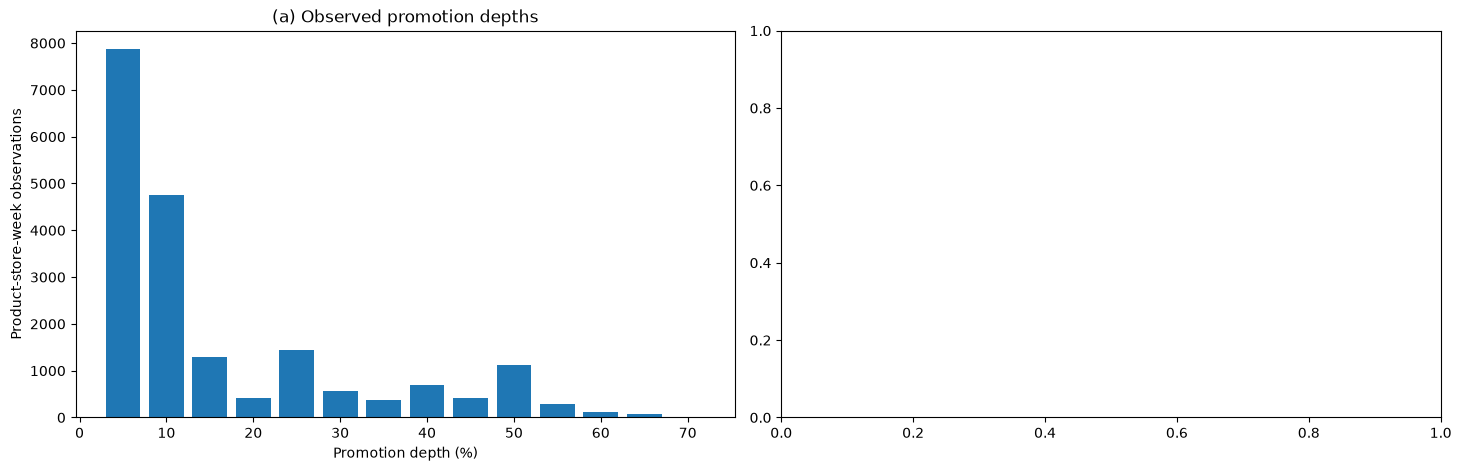

In [18]:
# Build the two-panel publication figure from empirical support and final behavioral draws.
CALIBRATION_DRAW_PATH = PROJECT_ROOT / "artifacts" / "calibration" / "product_behavioral_draws.pkl"
if not CALIBRATION_DRAW_PATH.exists():
    raise FileNotFoundError("Final behavioral draws are required for the model-implied effect panel. Run Notebook 04 first.")

pooled_depth_support = (
    support_source.groupby("depth_cluster", observed=True)
    .agg(promotion_observations=("move", "size"), products=("upc", "nunique"), panels=("store_upc", "nunique"))
    .reset_index().sort_values("depth_cluster")
)
depth_percent = 100.0 * pooled_depth_support["depth_cluster"]
total_promotion_observations = int(pooled_depth_support["promotion_observations"].sum())
behavioral_draws = pd.read_pickle(CALIBRATION_DRAW_PATH).copy()
behavioral_draws["upc"] = behavioral_draws["upc"].astype(str)
product_labels = product_lookup[["upc", "descrip", "size"]].copy()
product_labels["upc"] = product_labels["upc"].astype(str)
product_labels["product_label"] = product_labels["descrip"].astype(str).str.strip() + " (" + product_labels["size"].astype(str).str.strip() + ")"

reference_depth, post_weeks = 0.10, 4

def weighted_quantile(values, weights, probabilities):
    order = np.argsort(values)
    values = np.asarray(values, dtype=float)[order]
    cumulative_weight = np.cumsum(np.asarray(weights, dtype=float)[order])
    return np.interp(probabilities, cumulative_weight / cumulative_weight[-1], values)

post_effect_rows = []
for upc, draw_group in behavioral_draws.groupby("upc", observed=True):
    weights = draw_group["draw_weight"].to_numpy(dtype=float)
    if not np.isclose(weights.sum(), 1.0):
        raise AssertionError(f"Behavioral draw weights do not sum to one for {upc}.")
    state = np.full(len(draw_group), reference_depth, dtype=float)
    weekly_effects = []
    for _ in range(post_weeks):
        weekly_effects.append(draw_group["base_demand"].to_numpy(dtype=float) * (np.exp(-draw_group["displacement_strength"].to_numpy(dtype=float) * state) - 1.0))
        state = draw_group["inventory_persistence"].to_numpy(dtype=float) * state
    draw_effect = np.mean(np.vstack(weekly_effects), axis=0)
    lower, median, upper = weighted_quantile(draw_effect, weights, [0.05, 0.50, 0.95])
    post_effect_rows.append({"upc": upc, "mean_effect": float(np.dot(draw_effect, weights)), "median_effect": float(median), "effect_p05": float(lower), "effect_p95": float(upper), "reference_depth_percent": 100.0 * reference_depth, "post_promotion_weeks": post_weeks})

model_implied_post_effects = (
    pd.DataFrame(post_effect_rows)
    .merge(product_labels[["upc", "product_label"]], on="upc", how="left", validate="one_to_one")
    .sort_values("mean_effect", ascending=False).reset_index(drop=True)
)
if model_implied_post_effects["product_label"].isna().any():
    raise AssertionError("Missing product labels in model-implied effect figure.")
model_implied_post_effects.to_csv(TABLE_DIR / "paper_model_implied_post_promotion_effects.csv", index=False)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14.5, 4.6), constrained_layout=True)
axes[0].bar(depth_percent, pooled_depth_support["promotion_observations"], width=4.0)
axes[0].set_xlabel("Promotion depth (%)")
axes[0].set_ylabel("Product-store-week observations")
axes[0].set_title("(a) Observed promotion depths")
minimum_depth = int(5 * np.floor(depth_percent.min() / 5))
maximum_depth = int(5 * np.ceil(depth_percent.max() / 5))


In [19]:
# Finish panel (a) and draw the product-level model-implied post-promotion effects.
axes[0].set_xticks(np.arange(minimum_depth, maximum_depth + 1, 5))
axes[0].set_xlim(minimum_depth - 3, maximum_depth + 3)
axes[0].text(0.98, 0.95, rf"$N={total_promotion_observations:,}$", transform=axes[0].transAxes, ha="right", va="top")

plot_effects = model_implied_post_effects.iloc[::-1].reset_index(drop=True)
y_position = np.arange(len(plot_effects))
axes[1].hlines(y_position, plot_effects["effect_p05"], plot_effects["effect_p95"], color="#8db9d8", linewidth=2.3, zorder=1)
axes[1].scatter(plot_effects["mean_effect"], y_position, color="#1f77b4", s=40, zorder=2)
axes[1].axvline(0.0, color="#1f77b4", linestyle=":", linewidth=1.0)
axes[1].set_yticks(y_position, plot_effects["product_label"])
axes[1].set_xlabel("Average predicted weekly sales effect, post-promotion weeks 1-4")
axes[1].set_title("(b) Model-implied post-promotion effects")


Text(0.5, 1.0, '(b) Model-implied post-promotion effects')

In [20]:
# No legend or inset: the panel is a self-contained product-level forest plot.
post_event_path = pd.DataFrame()


In [21]:
# No inset: panel (b) is a self-contained product-level forest plot.


In [22]:
# Export the revised publication figure in both raster and vector formats.
figure_png_path = FIGURE_DIR / "paper_promotion_depths_and_model_implied_post_effects.png"
figure_pdf_path = FIGURE_DIR / "paper_promotion_depths_and_model_implied_post_effects.pdf"
fig.savefig(figure_png_path, dpi=300, bbox_inches="tight")
fig.savefig(figure_pdf_path, bbox_inches="tight")
plt.show()
print("Saved:", figure_png_path)
print("Saved:", figure_pdf_path)


Saved: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\figures\paper_promotion_depths_and_model_implied_post_effects.png
Saved: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\figures\paper_promotion_depths_and_model_implied_post_effects.pdf


## 10. Export descriptive tables and figures

In [23]:
# Define stable output filenames and export the main product-characteristics table.
output_paths = {
    "paper product table CSV": (
        TABLE_DIR / "paper_product_characteristics.csv"
    ),
    "paper product table LaTeX": (
        TABLE_DIR / "paper_product_characteristics.tex"
    ),
    "sample summary CSV": (
        TABLE_DIR / "paper_sample_summary.csv"
    ),
    "descriptive statistics CSV": (
        TABLE_DIR / "paper_descriptive_statistics.csv"
    ),
    "descriptive statistics LaTeX": (
        TABLE_DIR / "paper_descriptive_statistics.tex"
    ),
    "split summary CSV": (
        TABLE_DIR / "paper_split_summary.csv"
    ),
    "promotion episodes CSV": (
        TABLE_DIR / "paper_promotion_episodes.csv"
    ),
    "isolated events CSV": (
        TABLE_DIR / "paper_isolated_promotion_events.csv"
    ),
    "residualized event path CSV": (
        TABLE_DIR
        / "paper_promotion_event_path_residualized.csv"
    ),
    "raw event path diagnostic CSV": (
        TABLE_DIR
        / "paper_promotion_event_path_raw_diagnostic.csv"
    ),
    "event windows with baseline Parquet": (
        PROCESSED_DIR
        / "paper_isolated_event_windows_with_ppml_baseline.parquet"
    ),
    "depth support CSV": (
        TABLE_DIR / "paper_promotion_depth_support.csv"
    ),
    "admissible depths CSV": (
        TABLE_DIR / "paper_admissible_promotion_depths.csv"
    ),
}

# Write machine-readable and LaTeX versions of the main product table.
paper_product_table.to_csv(
    output_paths["paper product table CSV"],
    index=False,
)

paper_product_table.to_latex(
    output_paths["paper product table LaTeX"],
    index=False,
    escape=True,
    caption=(
        "Selected products and empirical promotion support."
    ),
    label="tab:product_characteristics",
)

In [24]:
# Export the remaining tables, diagnostics, event windows, and promotion-support files.
sample_summary.to_csv(
    output_paths["sample summary CSV"],
    header=True,
)

descriptive_table.to_csv(
    output_paths["descriptive statistics CSV"],
    index=False,
)

descriptive_table.to_latex(
    output_paths["descriptive statistics LaTeX"],
    index=False,
    float_format="%.3f",
    caption="Descriptive statistics for the selected sample.",
    label="tab:descriptive_statistics",
)

split_summary.to_csv(
    output_paths["split summary CSV"],
    index=False,
)

promotion_episodes.to_csv(
    output_paths["promotion episodes CSV"],
    index=False,
)

isolated_events.to_csv(
    output_paths["isolated events CSV"],
    index=False,
)

residualized_event_path.to_csv(
    output_paths["residualized event path CSV"],
    index=False,
)

raw_event_path.to_csv(
    output_paths["raw event path diagnostic CSV"],
    index=False,
)

event_windows.to_parquet(
    output_paths["event windows with baseline Parquet"],
    index=False,
    engine="pyarrow",
    compression="zstd",
)

depth_support.to_csv(
    output_paths["depth support CSV"],
    index=False,
)

supported_candidates.to_csv(
    output_paths["admissible depths CSV"],
    index=False,
)

In [25]:
# Print a compact audit trail of every file written by this notebook.
print("Saved paper outputs:")

for label, path in output_paths.items():
    print(f"  {label}: {path}")

Saved paper outputs:
  paper product table CSV: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\paper_product_characteristics.csv
  paper product table LaTeX: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\paper_product_characteristics.tex
  sample summary CSV: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\paper_sample_summary.csv
  descriptive statistics CSV: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\paper_descriptive_statistics.csv
  descriptive statistics LaTeX: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\paper_descriptive_statistics.tex
  split summary CSV: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\results\final\tables\paper_split_summary.csv
  promotion episodes CSV: C:\Users\janza\Desktop\dynamic_promotion_plan